(2400, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
None
(10009, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 

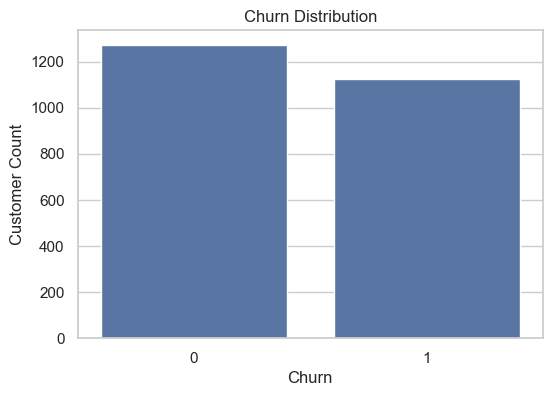

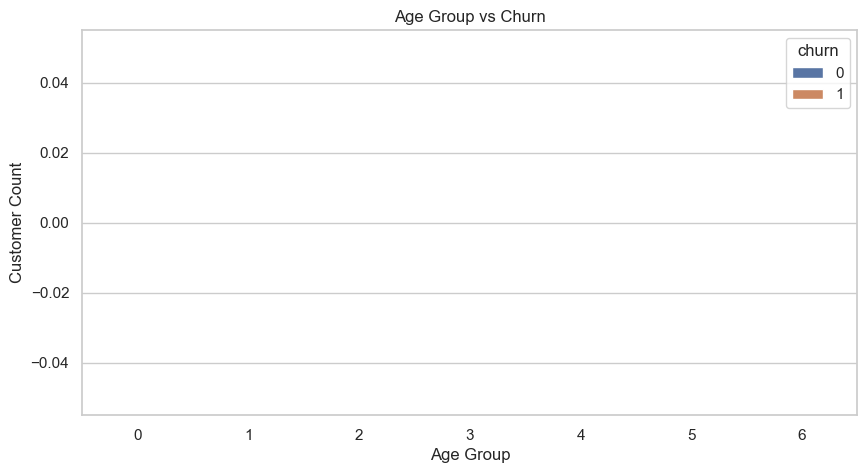

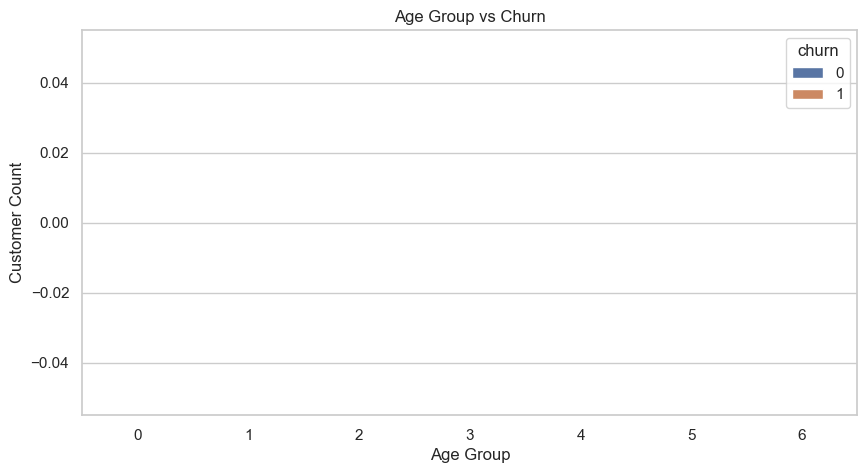

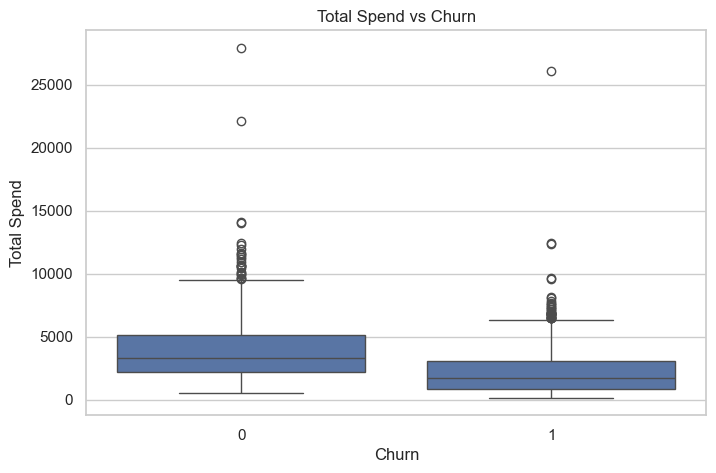

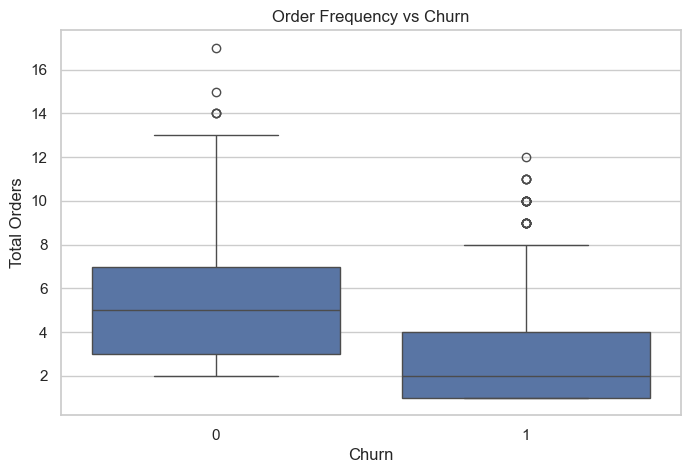

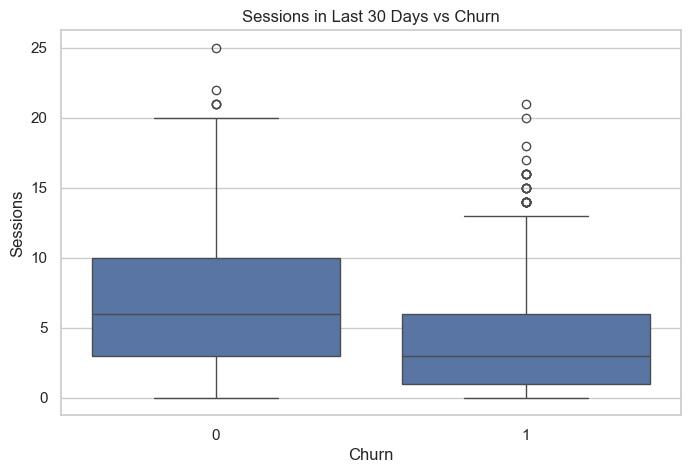

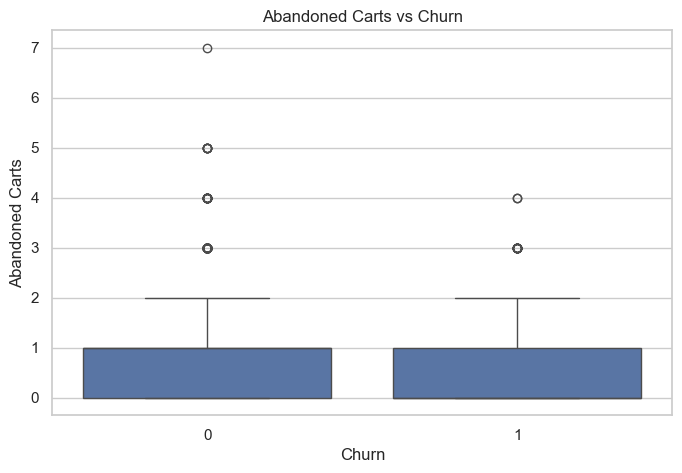

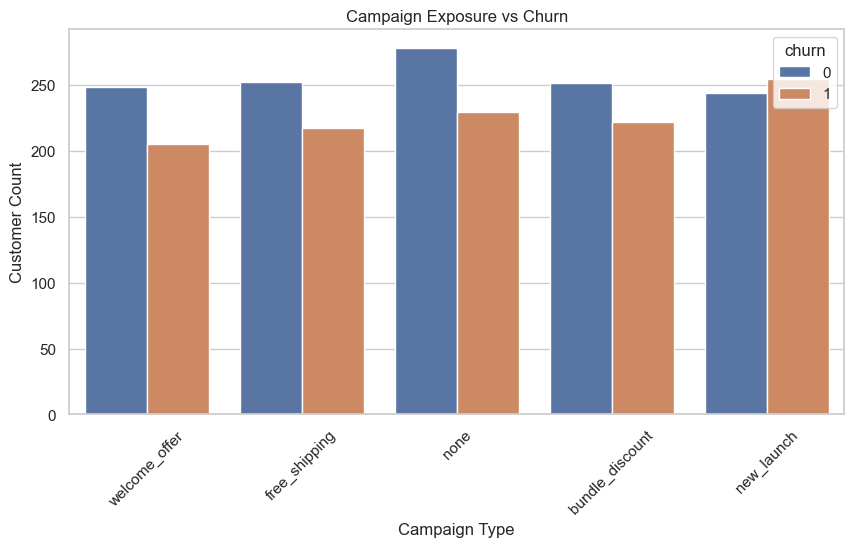

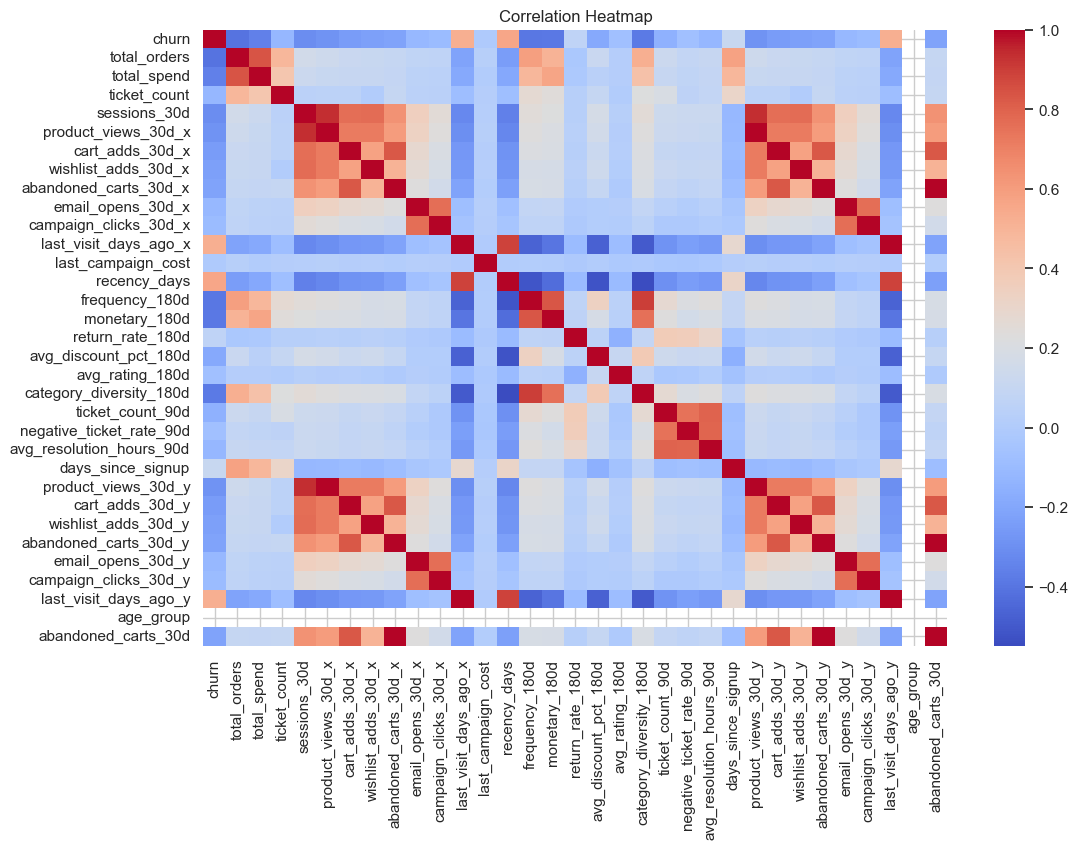

In [2]:
%run eda_audit.ipynb

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
print(orders.columns)

Index(['order_id', 'customer_id', 'order_date', 'category', 'quantity',
       'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating'],
      dtype='object')


In [5]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [6]:
snapshot_date = pd.to_datetime(orders['order_date']).max() + pd.Timedelta(days=1)

In [7]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

rfm = orders.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'nunique',                                   # Frequency
    'gross_amount': 'sum'                                    # Monetary
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

In [15]:
return_rate = orders.groupby('customer_id')['returned'].mean().reset_index()
return_rate.columns = ['customer_id', 'return_rate']

discount_usage = orders.groupby('customer_id')['discount_pct'].mean().reset_index()
discount_usage.columns = ['customer_id', 'avg_discount_pct']

rating = orders.groupby('customer_id')['rating'].mean().reset_index()
rating.columns = ['customer_id', 'avg_rating']

delivery = orders.groupby('customer_id')['delivery_days'].mean().reset_index()
delivery.columns = ['customer_id', 'avg_delivery_days']

In [17]:
rfm = rfm.merge(return_rate, on='customer_id', how='left')
rfm = rfm.merge(discount_usage, on='customer_id', how='left')
rfm = rfm.merge(rating, on='customer_id', how='left')
rfm = rfm.merge(delivery, on='customer_id', how='left')

In [16]:
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

In [19]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [20]:
return_rate = orders.groupby('customer_id')['returned'].mean().reset_index()
return_rate.columns = ['customer_id', 'return_rate']

In [21]:
discount_usage = orders.groupby('customer_id')['discount_pct'].mean().reset_index()
discount_usage.columns = ['customer_id', 'avg_discount_pct']

In [22]:
rating = orders.groupby('customer_id')['rating'].mean().reset_index()
rating.columns = ['customer_id', 'avg_rating']

In [23]:
delivery = orders.groupby('customer_id')['delivery_days'].mean().reset_index()
delivery.columns = ['customer_id', 'avg_delivery_days']

In [24]:
rfm['R_score'] = pd.qcut(
    rfm['recency'].rank(method='first'),
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [25]:
rfm = rfm.merge(return_rate, on='customer_id', how='left')
rfm = rfm.merge(discount_usage, on='customer_id', how='left')
rfm = rfm.merge(rating, on='customer_id', how='left')
rfm = rfm.merge(delivery, on='customer_id', how='left')

In [27]:
print(rfm.columns)

Index(['customer_id', 'recency', 'frequency', 'monetary', 'R_score', 'F_score',
       'M_score', 'RFM_score', 'return_rate_x', 'avg_discount_pct_x',
       'avg_rating_x', 'avg_delivery_days_x', 'return_rate_y',
       'avg_discount_pct_y', 'avg_rating_y', 'avg_delivery_days_y'],
      dtype='object')


In [28]:
rfm = rfm.drop(columns=[
    'return_rate_y',
    'avg_discount_pct_y',
    'avg_rating_y',
    'avg_delivery_days_y'
])

In [29]:
rfm = rfm.rename(columns={
    'return_rate_x': 'return_rate',
    'avg_discount_pct_x': 'avg_discount_pct',
    'avg_rating_x': 'avg_rating',
    'avg_delivery_days_x': 'avg_delivery_days'
})

In [30]:
print(rfm.columns)

Index(['customer_id', 'recency', 'frequency', 'monetary', 'R_score', 'F_score',
       'M_score', 'RFM_score', 'return_rate', 'avg_discount_pct', 'avg_rating',
       'avg_delivery_days'],
      dtype='object')


In [31]:
rfm[['return_rate',
     'avg_discount_pct',
     'avg_rating',
     'avg_delivery_days']] = rfm[[
     'return_rate',
     'avg_discount_pct',
     'avg_rating',
     'avg_delivery_days'
]].fillna(0)

In [32]:
def segment_customer(row):

    if row['recency'] <= 30 and row['frequency'] >= 8 and row['monetary'] >= 5000:
        return 'Champions'

    elif row['frequency'] >= 6:
        return 'Loyal Customers'

    elif row['recency'] > 120 and row['monetary'] >= 3000:
        return 'At Risk'

    elif row['avg_discount_pct'] >= 30:
        return 'Discount Sensitive'

    elif row['return_rate'] >= 0.5:
        return 'High Return Customers'

    elif row['recency'] > 180:
        return 'Dormant'

    else:
        return 'New Customers'

In [34]:
rfm['segment_name'] = rfm.apply(segment_customer, axis=1)

In [35]:
rfm['segment_name'].value_counts()

segment_name
New Customers            1096
Loyal Customers           540
Dormant                   405
At Risk                   135
Champions                 117
High Return Customers     107
Name: count, dtype: int64

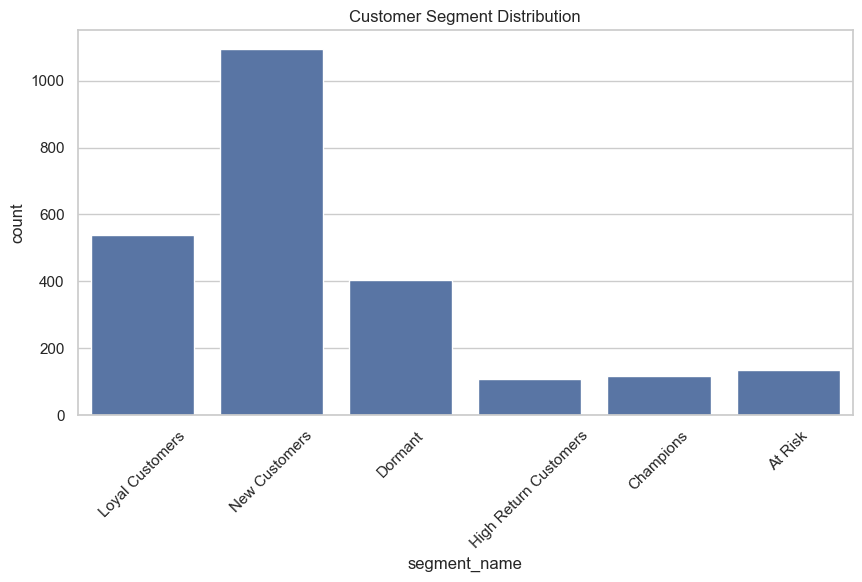

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(data=rfm, x='segment_name')

plt.xticks(rotation=45)

plt.title('Customer Segment Distribution')

plt.show()

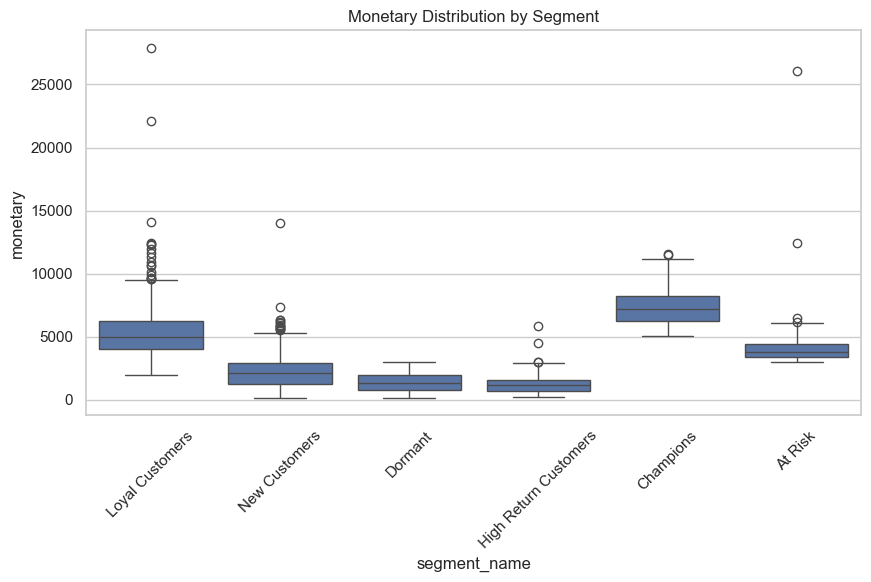

In [37]:
plt.figure(figsize=(10,5))

sns.boxplot(data=rfm, x='segment_name', y='monetary')

plt.xticks(rotation=45)

plt.title('Monetary Distribution by Segment')

plt.show()

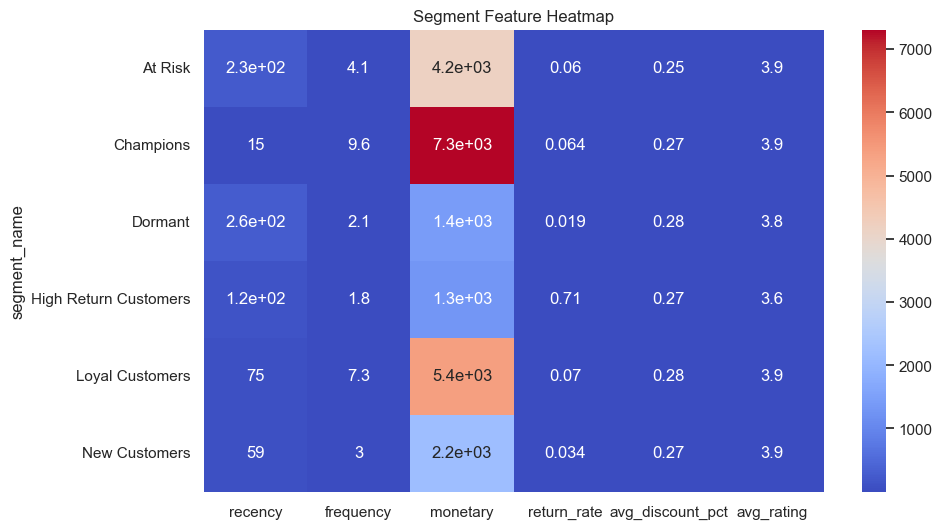

In [38]:
segment_summary = rfm.groupby('segment_name')[[
    'recency',
    'frequency',
    'monetary',
    'return_rate',
    'avg_discount_pct',
    'avg_rating'
]].mean()

plt.figure(figsize=(10,6))

sns.heatmap(segment_summary, annot=True, cmap='coolwarm')

plt.title('Segment Feature Heatmap')

plt.show()

In [39]:
rfm.to_csv('segments.csv', index=False)

*Champions*
  High frequency and high spending customers
  Strong retention value
*At Risk*
  Previously valuable customers with declining activity
  Require immediate intervention
*High Return Customers*
  Frequent product returns indicate dissatisfaction
*Dormant Customers*
  Very inactive customers with low engagement

In [42]:
import os

os.makedirs('outputs/charts', exist_ok=True)

In [43]:
plt.savefig('outputs/charts/segment_distribution.png')

<Figure size 640x480 with 0 Axes>